In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid")

COUNTRIES = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
COLORS = {
    'ethiopia': '#e74c3c',
    'kenya':    '#2ecc71',
    'sudan':    '#f39c12',
    'tanzania': '#3498db',
    'nigeria':  '#9b59b6'
}

print("Setup complete ")

Setup complete 


In [3]:
dfs = []

for country in COUNTRIES:
    path = f'../data/{country}_clean.csv'
    df = pd.read_csv(path, parse_dates=['Date'])
    df['Country'] = country.capitalize()
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined['Date'] = pd.to_datetime(combined['Date'])
combined['Month'] = combined['Date'].dt.month
combined['Year'] = combined['Date'].dt.year

print(f"Combined dataset shape: {combined.shape}")
print(f"\nCountries included: {combined['Country'].unique()}")
print(f"\nDate range: {combined['Date'].min()} → {combined['Date'].max()}")
combined.head()

Combined dataset shape: (20540, 16)

Countries included: <ArrowStringArray>
['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
Length: 5, dtype: str

Date range: 2015-01-01 00:00:00 → 2026-03-31 00:00:00


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


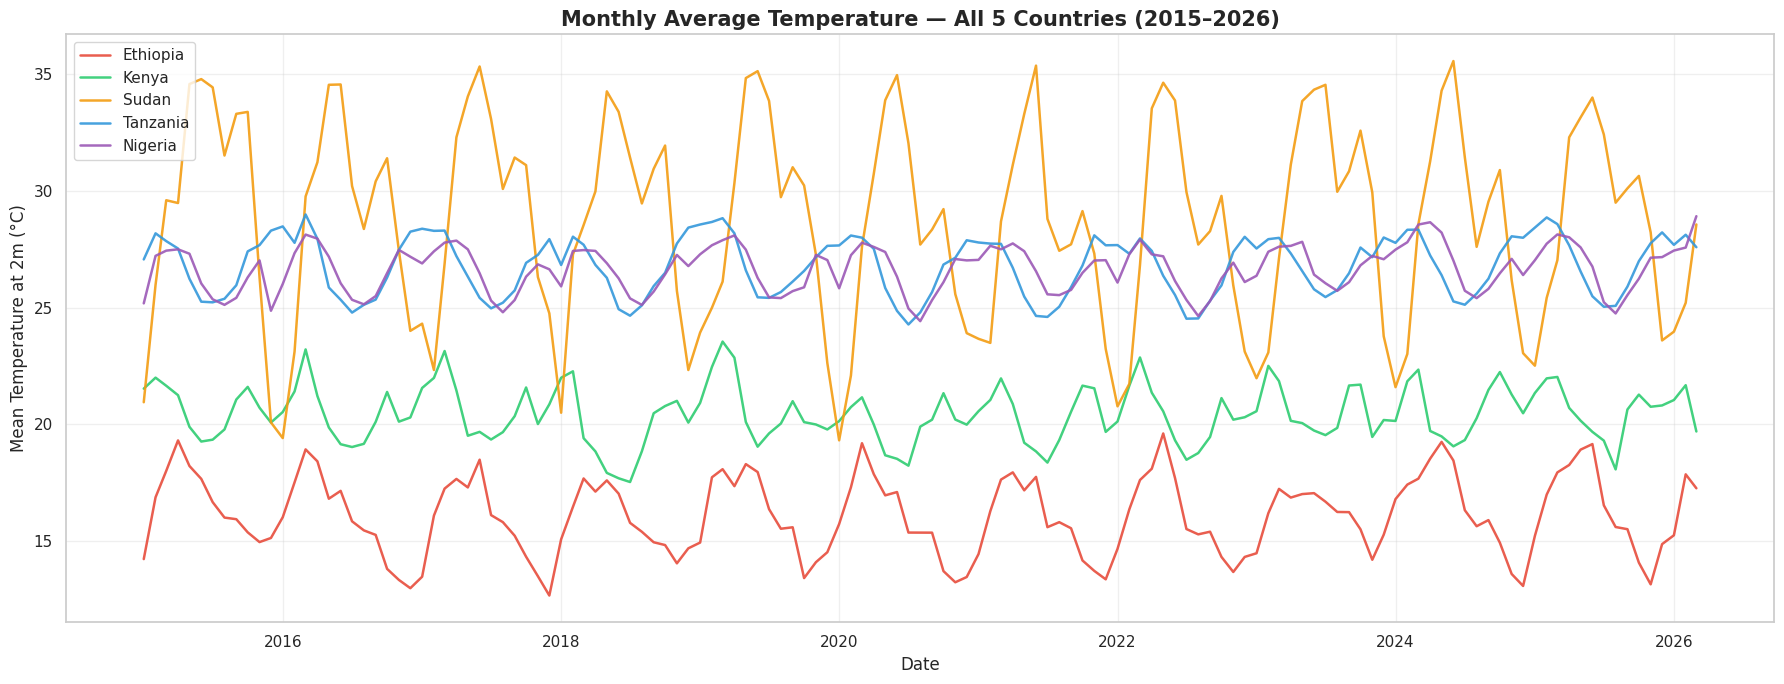

Chart saved ✅


In [4]:
fig, ax = plt.subplots(figsize=(18, 7))

for country in COUNTRIES:
    subset = combined[combined['Country'] == country.capitalize()]
    monthly = subset.groupby(subset['Date'].dt.to_period('M'))['T2M'].mean()
    monthly.index = monthly.index.to_timestamp()

    ax.plot(monthly.index, monthly.values,
            label=country.capitalize(),
            color=COLORS[country],
            linewidth=1.8, alpha=0.9)

ax.set_title('Monthly Average Temperature — All 5 Countries (2015–2026)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Temperature at 2m (°C)')
ax.legend(loc='upper left', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('temperature_trend_comparison.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [5]:
temp_stats = combined.groupby('Country')['T2M'].agg(
    Mean=lambda x: round(x.mean(), 2),
    Median=lambda x: round(x.median(), 2),
    Std_Dev=lambda x: round(x.std(), 2),
    Min=lambda x: round(x.min(), 2),
    Max=lambda x: round(x.max(), 2)
).reset_index()

temp_stats = temp_stats.sort_values('Mean', ascending=False)
temp_stats.columns = ['Country', 'Mean (°C)', 'Median (°C)', 
                       'Std Dev (°C)', 'Min (°C)', 'Max (°C)']

print("=== Temperature Summary Table ===")
print(temp_stats.to_string(index=False))
temp_stats

=== Temperature Summary Table ===
 Country  Mean (°C)  Median (°C)  Std Dev (°C)  Min (°C)  Max (°C)
   Sudan      28.76        29.16          4.68     14.72     37.99
Tanzania      26.80        26.99          1.33     22.83     29.97
 Nigeria      26.66        26.82          1.12     23.29     29.29
   Kenya      20.43        20.36          1.44     16.11     24.75
Ethiopia      16.07        16.04          1.90     10.37     21.53


,Country,Mean (°C),Median (°C),Std Dev (°C),Min (°C),Max (°C)
3,Sudan,28.76,29.16,4.68,14.72,37.99
4,Tanzania,26.80,26.99,1.33,22.83,29.97
2,Nigeria,26.66,26.82,1.12,23.29,29.29
1,Kenya,20.43,20.36,1.44,16.11,24.75
0,Ethiopia,16.07,16.04,1.90,10.37,21.53


## Temperature Trend Interpretation

From the table, Sudan has the highest average temperature at 28.76 °C. It also shows the greatest variability, with a standard deviation of 4.68 °C, indicating wider fluctuations compared to the other countries. Based on the chart, there appears to be a general upward warming trend across most countries from 2015 to 2026, although the increase is more gradual for some than others. Ethiopia has the lowest average temperature (16.07 °C) and remains significantly cooler than its neighbors like Kenya and Nigeria, with relatively moderate variability.

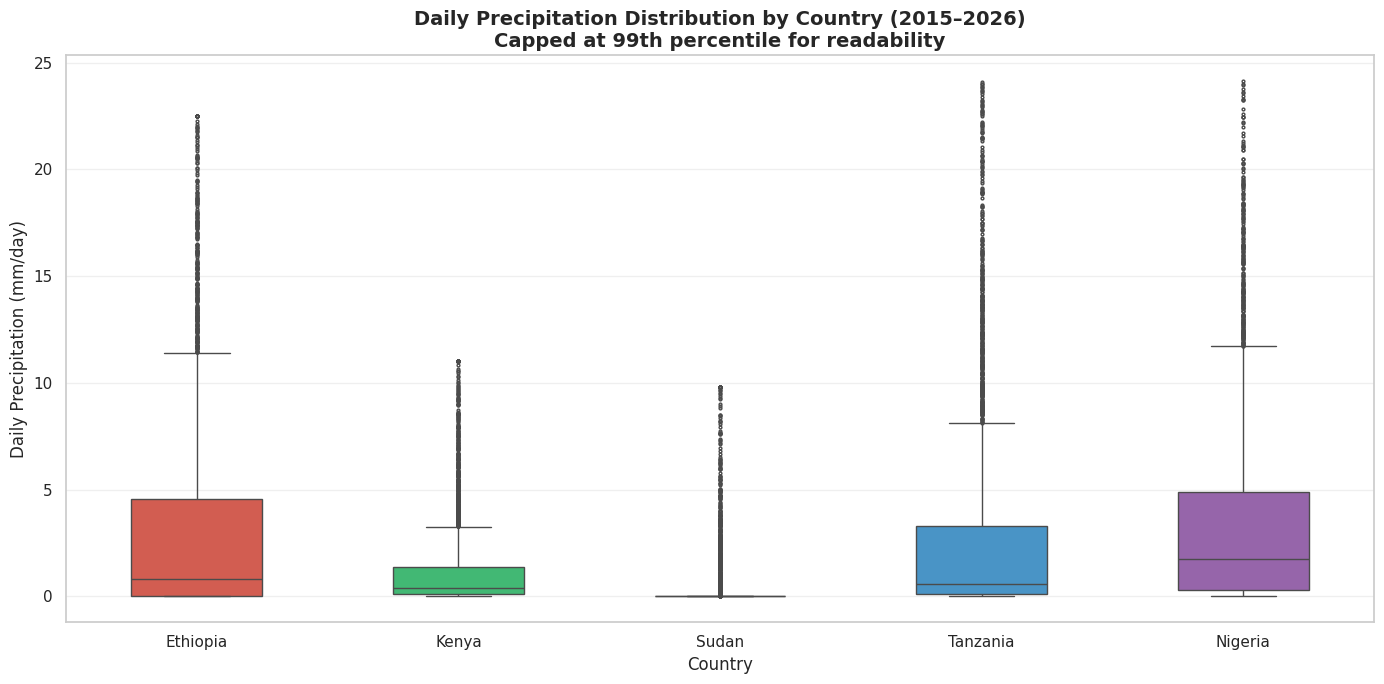

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

country_order = [c.capitalize() for c in COUNTRIES]
palette = {c.capitalize(): COLORS[c] for c in COUNTRIES}

# Cap at 99th percentile for readability
p99 = combined['PRECTOTCORR'].quantile(0.99)
plot_data = combined[combined['PRECTOTCORR'] <= p99]

sns.boxplot(data=plot_data, x='Country', y='PRECTOTCORR',
            order=country_order, palette=palette,
            width=0.5, fliersize=2, ax=ax)

ax.set_title('Daily Precipitation Distribution by Country (2015–2026)\n'
             'Capped at 99th percentile for readability',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Daily Precipitation (mm/day)')
plt.tight_layout()
plt.savefig('precipitation_boxplot_comparison.png', dpi=150)
plt.show()

In [7]:
precip_stats = combined.groupby('Country')['PRECTOTCORR'].agg(
    Mean=lambda x: round(x.mean(), 3),
    Median=lambda x: round(x.median(), 3),
    Std_Dev=lambda x: round(x.std(), 3),
    Max=lambda x: round(x.max(), 2),
    Rainy_Days=lambda x: (x >= 1).sum()
).reset_index()

precip_stats = precip_stats.sort_values('Mean', ascending=False)
precip_stats.columns = ['Country', 'Mean (mm/day)', 'Median (mm/day)',
                         'Std Dev', 'Max (mm/day)', 'Rainy Days (≥1mm)']

print("=== Precipitation Summary Table ===")
print(precip_stats.to_string(index=False))
precip_stats

=== Precipitation Summary Table ===
 Country  Mean (mm/day)  Median (mm/day)  Std Dev  Max (mm/day)  Rainy Days (≥1mm)
 Nigeria          3.951             1.84    5.455         26.01               2513
Ethiopia          3.441             0.82    5.375         22.50               1947
Tanzania          3.421             0.64    6.002         27.75               1805
   Kenya          1.324             0.38    2.283         11.01               1277
   Sudan          0.487             0.00    1.666          9.82                412


,Country,Mean (mm/day),Median (mm/day),Std Dev,Max (mm/day),Rainy Days (≥1mm)
2,Nigeria,3.951,1.84,5.455,26.01,2513
0,Ethiopia,3.441,0.82,5.375,22.50,1947
4,Tanzania,3.421,0.64,6.002,27.75,1805
1,Kenya,1.324,0.38,2.283,11.01,1277
3,Sudan,0.487,0.00,1.666,9.82,412


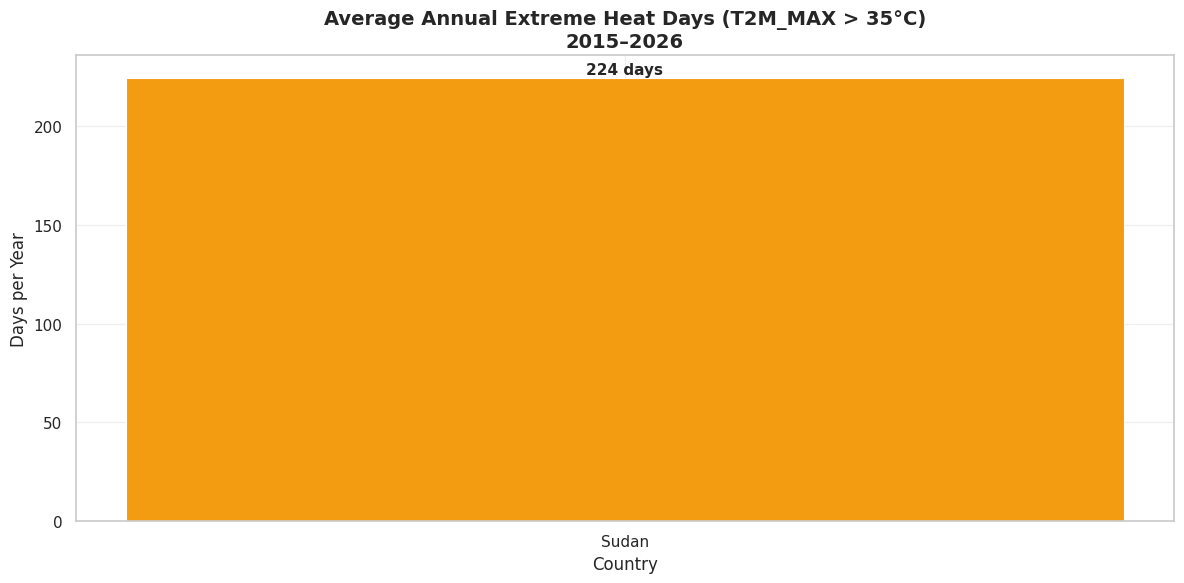

In [8]:
# Count days per year where T2M_MAX > 35°C
heat_days = (combined[combined['T2M_MAX'] > 35]
             .groupby(['Country', 'Year'])
             .size()
             .reset_index(name='Extreme_Heat_Days'))

heat_avg = heat_days.groupby('Country')['Extreme_Heat_Days'].mean().round(1)
heat_avg = heat_avg.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(heat_avg.index, heat_avg.values,
              color=[COLORS[c.lower()] for c in heat_avg.index],
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, heat_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f} days', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Average Annual Extreme Heat Days (T2M_MAX > 35°C)\n2015–2026',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Days per Year')
plt.tight_layout()
plt.savefig('extreme_heat_days.png', dpi=150)
plt.show()

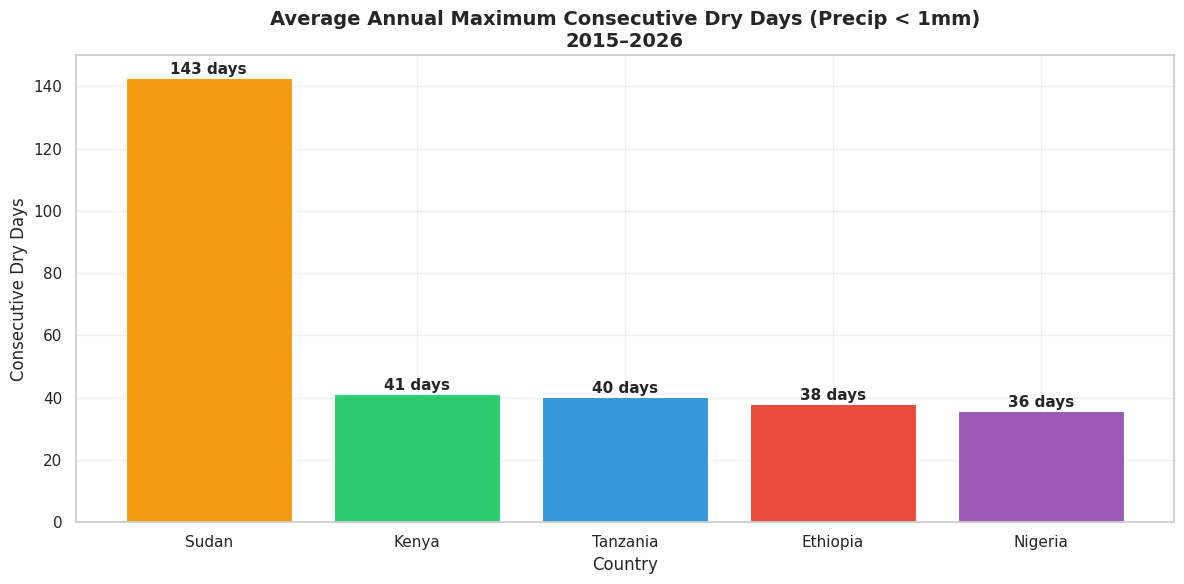

In [9]:
def count_max_consecutive_dry(series, threshold=1.0):
    """Count max consecutive dry days (precip < threshold) in a series."""
    max_streak = 0
    streak = 0
    for val in series:
        if val < threshold:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dry_streaks = []

for country in COUNTRIES:
    subset = combined[combined['Country'] == country.capitalize()].sort_values('Date')
    for year in subset['Year'].unique():
        year_data = subset[subset['Year'] == year]['PRECTOTCORR']
        streak = count_max_consecutive_dry(year_data.values)
        dry_streaks.append({
            'Country': country.capitalize(),
            'Year': year,
            'Max_Dry_Streak': streak
        })

dry_df = pd.DataFrame(dry_streaks)
dry_avg = dry_df.groupby('Country')['Max_Dry_Streak'].mean().round(1)
dry_avg = dry_avg.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(dry_avg.index, dry_avg.values,
              color=[COLORS[c.lower()] for c in dry_avg.index],
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, dry_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f} days', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Average Annual Maximum Consecutive Dry Days (Precip < 1mm)\n2015–2026',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Consecutive Dry Days')
plt.tight_layout()
plt.savefig('consecutive_dry_days.png', dpi=150)
plt.show()

In [11]:
from scipy.stats import kruskal

groups = [
    combined[combined['Country'] == c.capitalize()]['T2M'].dropna().values
    for c in COUNTRIES
]

stat, p_value = kruskal(*groups)

print("=== Kruskal-Wallis Test on T2M across all 5 countries ===")
print(f"Test Statistic : {stat:.4f}")
print(f"P-value        : {p_value:.2e}")
print()
if p_value < 0.05:
    print(" Result: SIGNIFICANT difference in temperature distributions")
    print("   The five countries have statistically distinct temperature profiles.")
else:
    print("Result: No significant difference detected (p ≥ 0.05)")

=== Kruskal-Wallis Test on T2M across all 5 countries ===
Test Statistic : 15396.9560
P-value        : 0.00e+00

 Result: SIGNIFICANT difference in temperature distributions
   The five countries have statistically distinct temperature profiles.


In [12]:
# Build a scoring table across 3 dimensions
# Higher score = more vulnerable

# 1. Mean temperature score (rank 1–5, hottest = most vulnerable)
temp_rank = temp_stats.set_index('Country')['Mean (°C)'].rank(ascending=False)

# 2. Precipitation std dev score (most variable = most vulnerable)
precip_rank = precip_stats.set_index('Country')['Std Dev'].rank(ascending=False)

# 3. Extreme heat days score
heat_rank = heat_avg.rank(ascending=False)

# 4. Dry days score
dry_rank = dry_avg.rank(ascending=False)

# Combine into vulnerability score (lower total rank = more vulnerable)
vuln = pd.DataFrame({
    'Temp Rank':       temp_rank,
    'Precip Variability Rank': precip_rank,
    'Heat Days Rank':  heat_rank,
    'Dry Days Rank':   dry_rank,
})

vuln['Total Score'] = vuln.sum(axis=1)
vuln['Vulnerability Rank'] = vuln['Total Score'].rank().astype(int)
vuln = vuln.sort_values('Vulnerability Rank')

print("=== Climate Vulnerability Ranking (1 = Most Vulnerable) ===")
print(vuln.to_string())
vuln

=== Climate Vulnerability Ranking (1 = Most Vulnerable) ===
          Temp Rank  Precip Variability Rank  Heat Days Rank  Dry Days Rank  Total Score  Vulnerability Rank
Country                                                                                                     
Tanzania        2.0                      1.0             NaN            3.0          6.0                   1
Sudan           1.0                      5.0             1.0            1.0          8.0                   2
Nigeria         3.0                      2.0             NaN            5.0         10.0                   3
Kenya           4.0                      4.0             NaN            2.0         10.0                   3
Ethiopia        5.0                      3.0             NaN            4.0         12.0                   5


,Temp Rank,Precip Variability Rank,Heat Days Rank,Dry Days Rank,Total Score,Vulnerability Rank
Country,,,,,,
Tanzania,2.0,1.0,NaN,3.0,6.0,1
Sudan,1.0,5.0,1.0,1.0,8.0,2
Nigeria,3.0,2.0,NaN,5.0,10.0,3
Kenya,4.0,4.0,NaN,2.0,10.0,3
Ethiopia,5.0,3.0,NaN,4.0,12.0,5


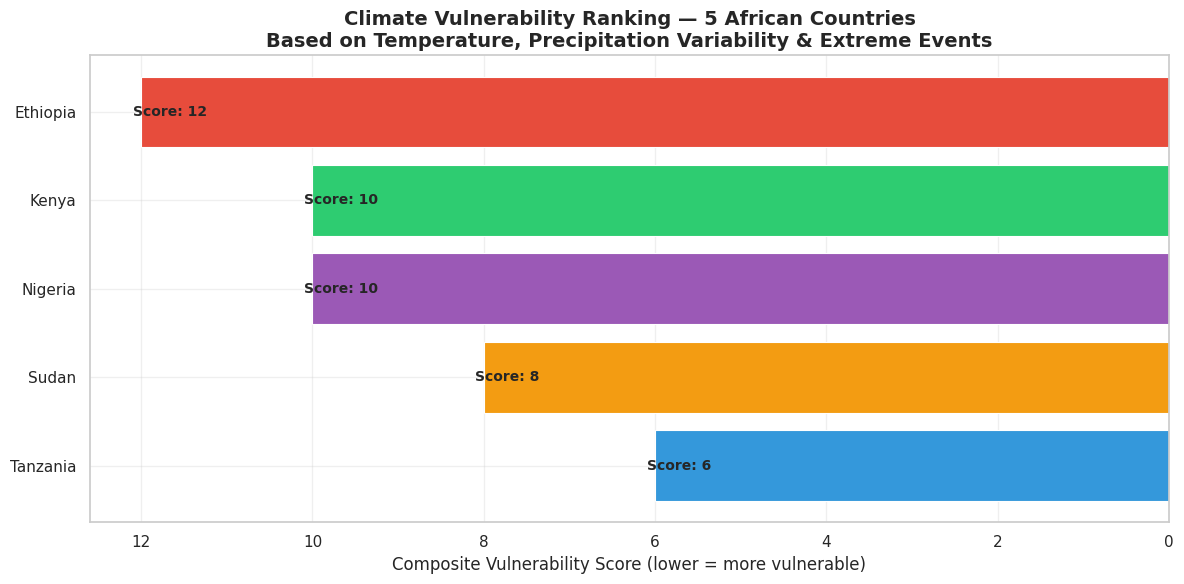

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

vuln_sorted = vuln.sort_values('Total Score', ascending=True)
bar_colors = [COLORS[c.lower()] for c in vuln_sorted.index]

bars = ax.barh(vuln_sorted.index, vuln_sorted['Total Score'],
               color=bar_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, vuln_sorted['Total Score']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'Score: {val:.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Climate Vulnerability Ranking — 5 African Countries\n'
             'Based on Temperature, Precipitation Variability & Extreme Events',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Composite Vulnerability Score (lower = more vulnerable)')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('vulnerability_ranking.png', dpi=150)
plt.show()

**1. Which country is warming fastest?**
Sudan appears to be warming the fastest, as it already has the highest mean temperature (28.76 °C) and the largest variability (std dev 4.68 °C), suggesting stronger upward shifts and more extreme heat swings over time. This pattern points to a steeper warming trajectory compared to the other countries, increasing climate stress in already hot regions.

**2. Which country has the most unstable precipitation?**
Tanzania shows the highest precipitation variability (std dev 6.002 mm/day), indicating large fluctuations between wet and dry periods. However, Nigeria also stands out with the highest mean rainfall (3.951 mm/day) and the most rainy days, highlighting frequent and intense rainfall variability that can drive both flooding and drought cycles.

**3. What do extreme heat and drought reveal?**
Sudan combines extreme heat (highest max temperature at 37.99 °C) with very low rainfall (0.487 mm/day and only 412 rainy days), signaling severe drought conditions. This combination reflects compounding climate stress—high evaporation, water scarcity, and declining agricultural productivity—which increases the risk of displacement and food insecurity.

**4. How does Ethiopia compare to its neighbors?**
Ethiopia has the lowest average temperature (16.07 °C), making it significantly cooler than neighbors like Kenya and Nigeria. However, it still experiences notable rainfall variability (std dev 5.375 mm/day) and a relatively high number of rainy days (1947), placing it in a moderate vulnerability position—less exposed to extreme heat, but still sensitive to rainfall inconsistency.

**5. Which country should Ethiopia champion for climate finance at COP32?**
The data strongly supports prioritizing Sudan for climate finance. With the highest heat exposure, extreme temperature variability, and the lowest rainfall levels, Sudan faces the most acute combined risks of heat stress and drought, making it a critical case for adaptation funding and loss-and-damage support.
